# CampusCare Practical 4: Student Wellness Analytics

This notebook uses a realistic CampusCare student wellness dataset to visualize study habits, sleep, stress, mood, screen time, and exercise patterns. The charts are created with Pandas for data loading and Matplotlib for visualization.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Load the CampusCare dataset and create the screenshot output folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'analytics' else current_dir
data_path = project_root / 'data' / 'student_wellness.csv'
output_dir = project_root / 'analytics' / 'screenshots'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
df.head()

,Student_ID,Study_Hours,Sleep_Hours,Stress_Level,Mood_Score,Screen_Time,Exercise_Hours
0,CCS001,2.5,7.8,4,8,4.1,1.2
1,CCS002,5.0,6.2,7,5,6.4,0.4
2,CCS003,3.5,7.1,5,7,5.0,0.8
3,CCS004,6.5,5.6,8,4,7.2,0.2
4,CCS005,1.8,8.2,3,8,3.6,1.5


## Bar Chart: Average Stress by Study-Hour Group

This bar chart groups students by daily study hours and compares the average stress level in each group. It helps CampusCare identify whether heavy study routines may need extra balance support.

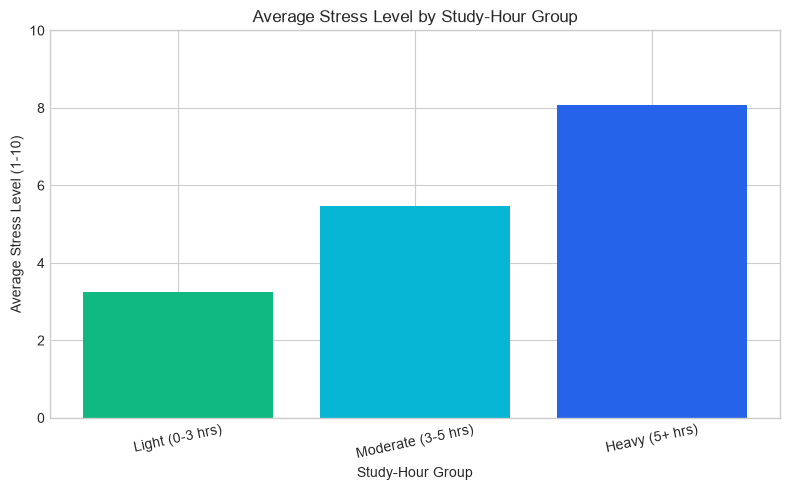

In [2]:
# This makes the chart cell safe to run directly, even if earlier cells were skipped.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Load the CampusCare dataset and create the screenshot output folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'analytics' else current_dir
data_path = project_root / 'data' / 'student_wellness.csv'
output_dir = project_root / 'analytics' / 'screenshots'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

# Create practical study-hour groups for easier comparison.
study_bins = [0, 3, 5, 8]
study_labels = ['Light (0-3 hrs)', 'Moderate (3-5 hrs)', 'Heavy (5+ hrs)']
df['Study_Group'] = pd.cut(df['Study_Hours'], bins=study_bins, labels=study_labels, include_lowest=True)
stress_by_group = df.groupby('Study_Group', observed=False)['Stress_Level'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(stress_by_group.index.astype(str), stress_by_group.values, color=['#10B981', '#06B6D4', '#2563EB'])
ax.set_title('Average Stress Level by Study-Hour Group')
ax.set_xlabel('Study-Hour Group')
ax.set_ylabel('Average Stress Level (1-10)')
ax.set_ylim(0, 10)
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig(output_dir / 'bar_stress_by_study_group.png', dpi=160)
plt.show()

## Line Chart: Mood Trend Across Student Records

This line chart shows mood scores across the 40 student records. In a real portal, a similar trend could be used to monitor changes in student wellbeing over time or across check-ins.

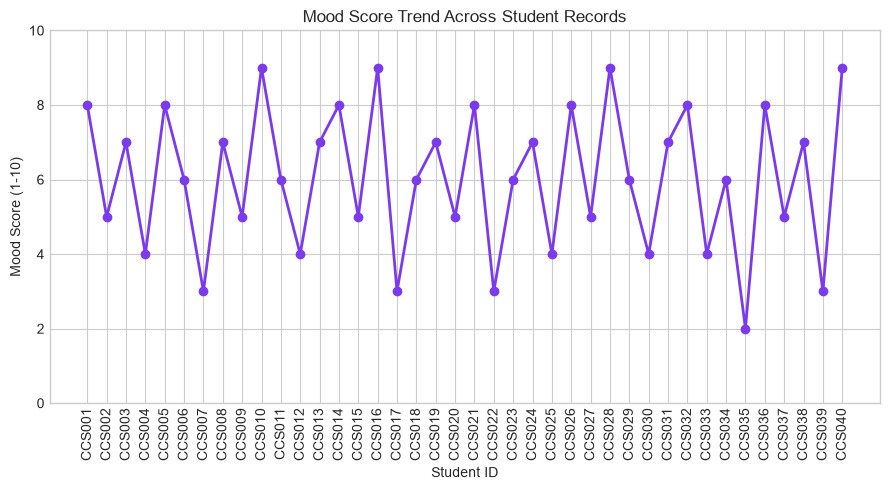

In [3]:
# This makes the chart cell safe to run directly, even if earlier cells were skipped.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Load the CampusCare dataset and create the screenshot output folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'analytics' else current_dir
data_path = project_root / 'data' / 'student_wellness.csv'
output_dir = project_root / 'analytics' / 'screenshots'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df['Student_ID'], df['Mood_Score'], marker='o', linewidth=2, color='#7C3AED')
ax.set_title('Mood Score Trend Across Student Records')
ax.set_xlabel('Student ID')
ax.set_ylabel('Mood Score (1-10)')
ax.set_ylim(0, 10)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(output_dir / 'line_mood_trend.png', dpi=160)
plt.show()

## Scatter Plot: Sleep Hours vs Stress Level

This scatter plot compares sleep duration with stress level. It helps reveal whether students sleeping fewer hours tend to report higher stress.

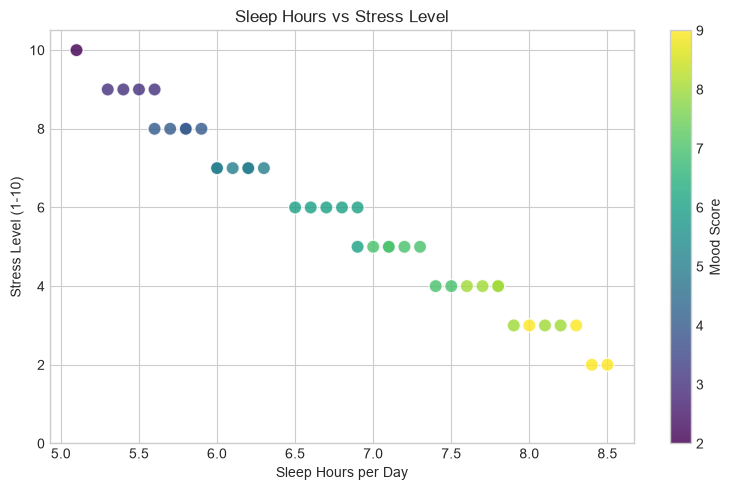

In [4]:
# This makes the chart cell safe to run directly, even if earlier cells were skipped.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Load the CampusCare dataset and create the screenshot output folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'analytics' else current_dir
data_path = project_root / 'data' / 'student_wellness.csv'
output_dir = project_root / 'analytics' / 'screenshots'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df['Sleep_Hours'], df['Stress_Level'], c=df['Mood_Score'], cmap='viridis', s=90, alpha=0.82, edgecolor='white')
ax.set_title('Sleep Hours vs Stress Level')
ax.set_xlabel('Sleep Hours per Day')
ax.set_ylabel('Stress Level (1-10)')
ax.set_ylim(0, 10.5)
colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label('Mood Score')
plt.tight_layout()
plt.savefig(output_dir / 'scatter_sleep_vs_stress.png', dpi=160)
plt.show()

## Histogram: Screen Time Distribution

This histogram shows how daily screen time is distributed across the dataset. CampusCare can use this kind of view to understand digital load and encourage healthier device habits.

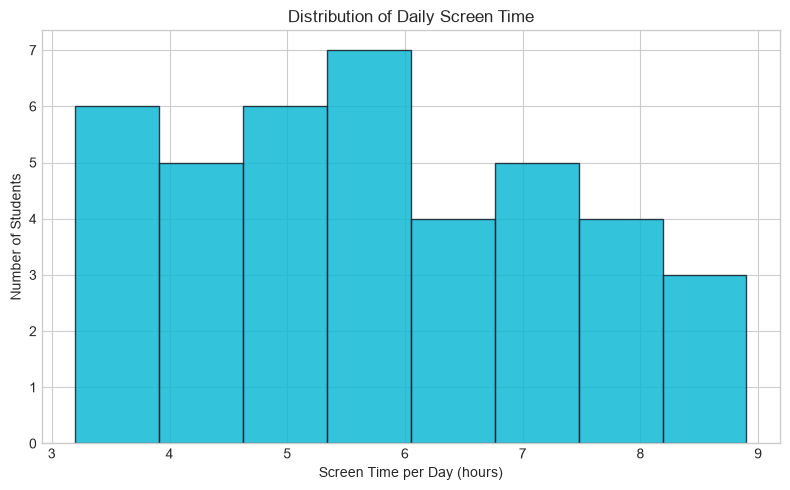

In [5]:
# This makes the chart cell safe to run directly, even if earlier cells were skipped.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Load the CampusCare dataset and create the screenshot output folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'analytics' else current_dir
data_path = project_root / 'data' / 'student_wellness.csv'
output_dir = project_root / 'analytics' / 'screenshots'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Screen_Time'], bins=8, color='#06B6D4', edgecolor='#111827', alpha=0.82)
ax.set_title('Distribution of Daily Screen Time')
ax.set_xlabel('Screen Time per Day (hours)')
ax.set_ylabel('Number of Students')
plt.tight_layout()
plt.savefig(output_dir / 'histogram_screen_time.png', dpi=160)
plt.show()

## Pie Chart: Wellness Risk Categories

This pie chart classifies students into wellness risk categories using stress and sleep signals. It gives a quick high-level snapshot of how many students may need additional support.

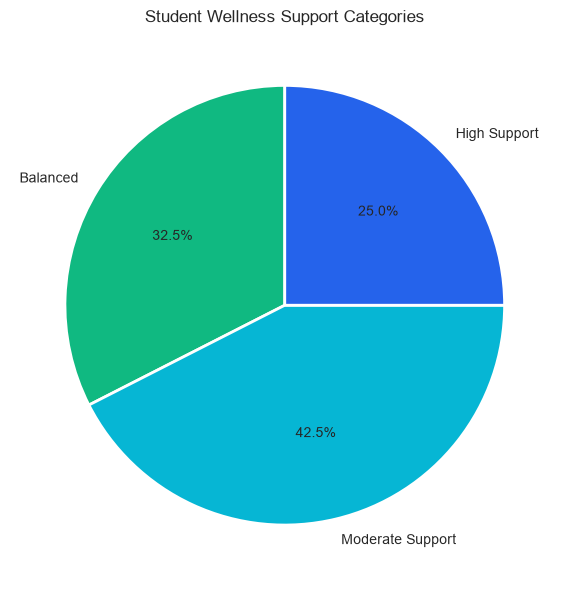

In [6]:
# This makes the chart cell safe to run directly, even if earlier cells were skipped.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Load the CampusCare dataset and create the screenshot output folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'analytics' else current_dir
data_path = project_root / 'data' / 'student_wellness.csv'
output_dir = project_root / 'analytics' / 'screenshots'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

# A simple CampusCare rule: higher stress and lower sleep increase support priority.
def classify_wellness(row):
    if row['Stress_Level'] >= 8 or row['Sleep_Hours'] < 6:
        return 'High Support'
    if row['Stress_Level'] >= 5 or row['Sleep_Hours'] < 7:
        return 'Moderate Support'
    return 'Balanced'

df['Wellness_Category'] = df.apply(classify_wellness, axis=1)
category_counts = df['Wellness_Category'].value_counts().reindex(['Balanced', 'Moderate Support', 'High Support'])

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#10B981', '#06B6D4', '#2563EB'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
ax.set_title('Student Wellness Support Categories')
plt.tight_layout()
plt.savefig(output_dir / 'pie_wellness_categories.png', dpi=160)
plt.show()

## Summary

The visualizations show how CampusCare can transform simple student wellness check-in data into actionable insights about stress, sleep, mood, screen time, and support needs.